# Ejercicio Introducción OLS - Base de datos de producción
Donde:
* K: Capital
* L: numero de trabajadores
* y: producción de leche

In [67]:
url = "https://raw.githubusercontent.com/it-ces/PUBLIC-AI/main/REGRESION/cobb-douglas-firm.csv"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(url)

In [68]:
df

,Unnamed: 0,K,L,y
0,0,10.448902,3.980349,8.498402
1,1,10.802293,2.125921,8.317644
2,2,10.630025,0.852183,6.175296
3,3,11.280932,4.112527,12.158838
4,4,10.376671,3.070118,8.945734
...,...,...,...,...
95,95,9.610686,5.571744,9.592110
96,96,10.707748,3.752217,8.846282
97,97,9.022959,1.920561,7.061450
98,98,10.476081,3.007337,10.188356


In [69]:
df.columns

Index(['Unnamed: 0', 'K', 'L', 'y'], dtype='str')

In [70]:
#borramos la columna Unnamed: 0
df.drop(columns=['Unnamed: 0'], inplace=True)

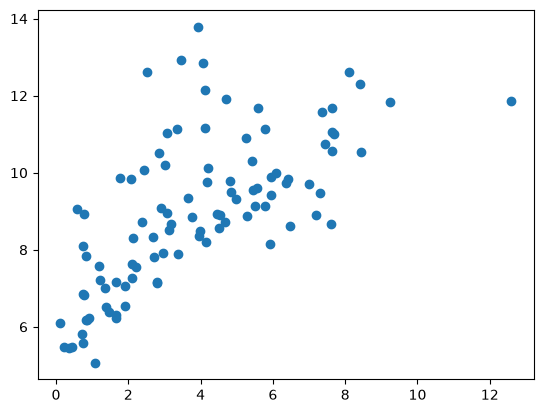

In [71]:
#Graficamos
plt.scatter(df['L'], df['y'])
#L: numero de trabajadores
#y: producción de leche

In [72]:
#Coeficiente de correlacion de Pearson
df.corr()

,K,L,y
K,1.000000,0.130581,0.454278
L,0.130581,1.000000,0.674986
y,0.454278,0.674986,1.000000


Podemos notar que existe un relación positiva "K" con "y" igual a 0.45
Podemos notar que existe un relación positiva "L" con "y" igual a 0.45

### ¿Cual es la mejor línea que se ajusta a estos datos dispersos?

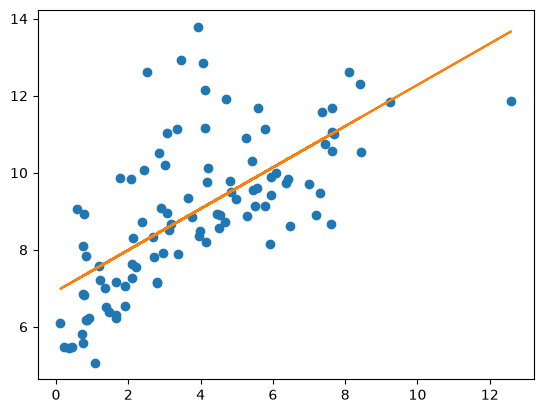

In [73]:
import matplotlib.pyplot as plt
x = df['L']
y = df['y']
#create basic scatterplot
plt.plot(x, y, 'o')
#obtain m (slope) and b(intercept) of linear regression line
m, b = np.polyfit(x, y, 1)
#add linear regression line to scatterplot
plt.plot(x, m*x+b)

In [74]:
df_l = df.copy()
df_l = df_l.apply(lambda row: row/df_l['L'])
df_1 = df_l.apply(lambda x: np.log(x)) #Se aplica logaritmo a todas las columnas del dataframe para linealizar los datos

In [75]:
df_l

,K,L,y
0,2.625122,1.0,2.135090
1,5.081229,1.0,3.912489
2,12.473871,1.0,7.246440
3,2.743066,1.0,2.956537
4,3.379894,1.0,2.913808
...,...,...,...
95,1.724897,1.0,1.721563
96,2.853712,1.0,2.357615
97,4.698084,1.0,3.676763
98,3.483508,1.0,3.387833


El siguiente codigo df_l = df_l.apply(lambda row: row/df_l['L']) podriamos explicarlo de la siguiente manera:
lo anterior podriamos entenderlo con una comparación: imaginemos que se tiene 500 maquinas (esto vendria a ser el capital) y tenemos 100 trabajadores, entonces podriamos decir que por cada trabajador se tiene 5 máquinas. De esta manera explicamos que tenemos K de capital y L trabajadores obtenemos cuanta plata tiene para trabajar cada trabajadores y cuanto produce cada trabajador.


In [76]:
#LO SIGUIENTE ES SOLO UN EJEMPLO DE LO QUE LOGRAMOS CON LAMBDA, NO ES PARTE DEL EJERCICIO
test = pd.DataFrame({'var1': [10, 4, 5],
                    'var2' : [2, 2, 5]
                     })

In [77]:
#LO SIGUIENTE ES SOLO UN EJEMPLO DE LO QUE LOGRAMOS CON LAMBDA, NO ES PARTE DEL EJERCICIO
test.apply(lambda row: row/test['var2'])

,var1,var2
0,5.0,1.0
1,2.0,1.0
2,1.0,1.0


In [78]:
#CONTINUANDO CON EL EJERCICIO
df_l.drop(df_l[df_l['K']>22].index, inplace=True) #Eliminar filas donde K > 22 (posibles outliers de capital por trabajador)

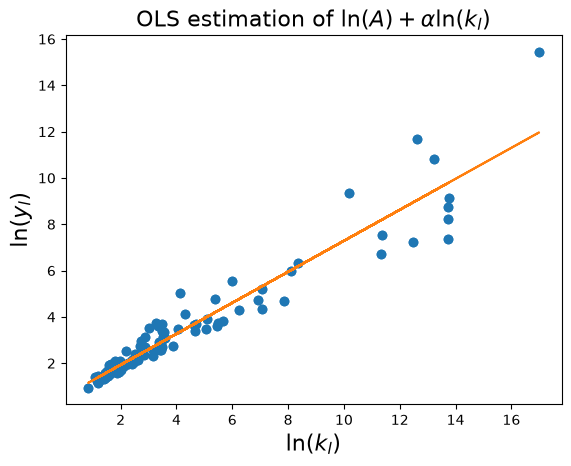

In [79]:
import matplotlib.pyplot as plt
plt.scatter(df_l['K'], df_l['y'])
x = df_l['K']
y = df_l['y']
#create basic scatterplot
plt.plot(x, y, 'o')
#obtain m (slope) and b(intercept) of linear regression line
m, b = np.polyfit(x, y, 1)
#add linear regression line to scatterplot
plt.plot(x, m*x+b)

plt.title(r'OLS estimation of $\ln(A) + \alpha \ln(k_{l})$', fontsize=16)
plt.xlabel(r'$\ln(k_{l})$', fontsize=16)
plt.ylabel(r'$\ln(y_{l})$', fontsize=16)
plt.savefig("production.eps")

* ln(kl): Logaritmo de capital portrabajador
* ln(yl): Logaritmo del producto por trabajador

***como se puede ver en la grafica aplicar logaritmo permite linealizar los datos**

In [80]:
import statsmodels.formula.api as smf

### Hallamos conclusiones con OLS con la Data sin procesar

In [81]:
# Ajustar un modelo OLS de "y" en función de "K" y mostrar el resumen estadístico
print(smf.ols(formula='y ~ K', data=df).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.206
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     25.48
Date:                Tue, 11 Aug 2026   Prob (F-statistic):           2.06e-06
Time:                        16:50:30   Log-Likelihood:                -198.32
No. Observations:                 100   AIC:                             400.6
Df Residuals:                      98   BIC:                             405.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1736      1.825     -0.095      0.9

##### CONCLUSIÓN
* **por cada unidad de capital adicional optengo en promedio 0.9046 unidades de producción**

### Hallamos conclusiones con OLS con la Data procesada aplicando divicion entre "L" y aplicando logaritmo

In [82]:
#Ajustar un modelo OLS de "y" en función de "K" sobre el dataframe transformado df_l y mostrar el resumen estadístico
print(smf.ols(formula='y ~ K', data=df_l).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     974.1
Date:                Tue, 11 Aug 2026   Prob (F-statistic):           2.12e-51
Time:                        16:50:30   Log-Likelihood:                -109.36
No. Observations:                  96   AIC:                             222.7
Df Residuals:                      94   BIC:                             227.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5907      0.119      4.950      0.0

TEORICAMENTE AQUI EXPLICAREMOS EN QUE PORCENTAJE INCREMENTA "Y" CUANDO "X" INCREMENTA EN 1 PORCIENTO

##### CONCLUSIÓN
* **Cuando K(la razon capital por trabajador) incremente en 1% y (razon producto por trabajador) incrementa en 0.6695%**